Generating underlying price paths...
Running Monte Carlo simulation of arbitrage trades...

Trades executed: 1000

Exit reason counts:
exit_reason
stop_loss    1000
Name: count, dtype: int64

P&L summary (total per trade):
count    1000.000000
mean     -191.923051
std         6.407947
min      -196.320888
25%      -195.825971
50%      -194.378268
75%      -190.581750
max      -126.163262
Name: total_pnl, dtype: float64

Average P&L per trade: $-191.92
Win rate: 0.0%

P&L histogram saved to /tmp/cash_margin_arbitrage_pnl.png
Sample path plot saved to /tmp/cash_margin_sample_path.png

--- Sensitivity Analysis ---
Varying vol margin (x):
  margin x = 0.02: initial spread = $0.5556
  margin x = 0.05: initial spread = $1.3892
  margin x = 0.08: initial spread = $2.2228
  margin x = 0.10: initial spread = $2.7784

Varying transaction cost:
  tc = 0.0005: entry threshold = $0.1000
  tc = 0.0010: entry threshold = $0.2000
  tc = 0.0020: entry threshold = $0.4000

--- Key Takeaways ---
1. Entry

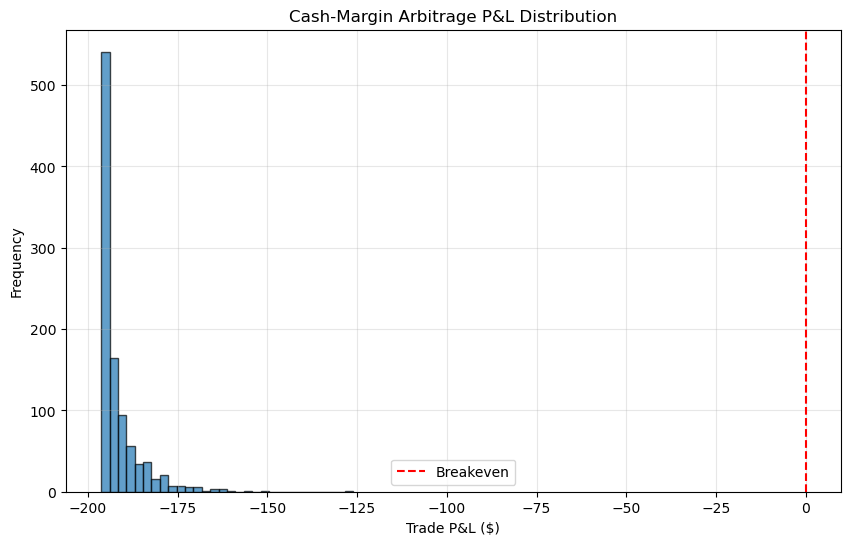

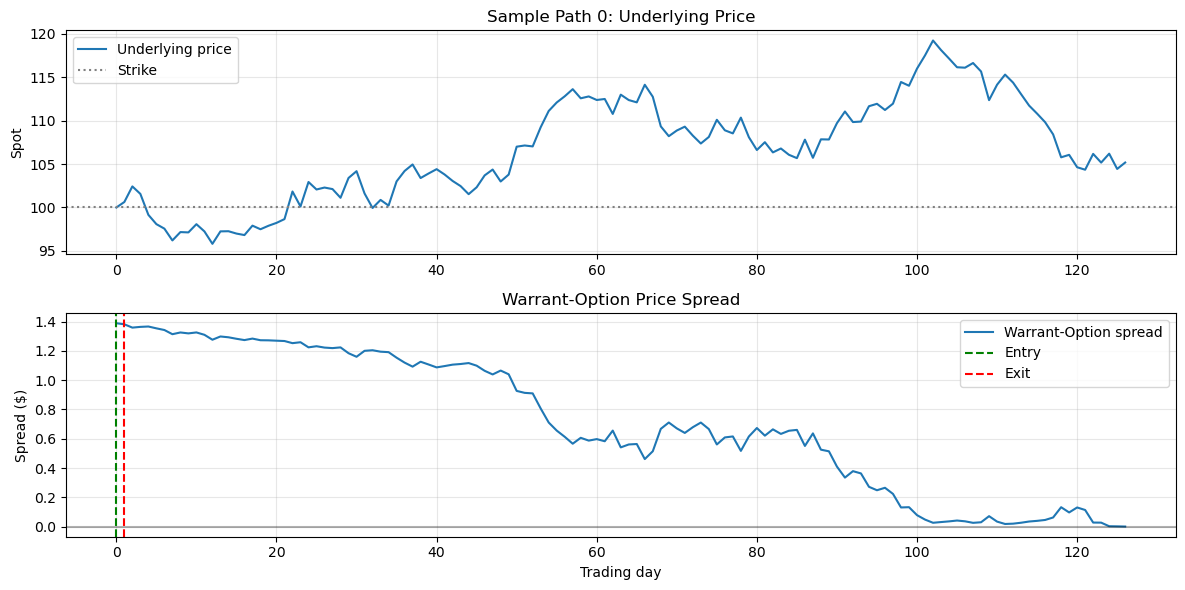

In [1]:
from cash_margin_arbitrage_simulation import *


=== REPLICATION RESULTS (σ_spot=20%, n_samples=100_000) ===
 Type Strike  Theo E[PNL]   Num E[PNL]    MC E[PNL] MC std err  |Theo-MC|
-------------------------------------------------------------------------------------
call      80    -0.079536    -0.079536    -0.080131     0.0016   5.94e-04
call      90    -0.369724    -0.369724    -0.370568     0.0015   8.44e-04
call     100    -0.510324    -0.510324    -0.511111     0.0016   7.87e-04
call     110    -0.430336    -0.430336    -0.430684     0.0020   3.48e-04
call     120    -0.216602    -0.216602    -0.216290     0.0024   3.12e-04
call     130     0.008100     0.008100     0.009045     0.0027   9.45e-04
call     140     0.169004     0.169004     0.170372     0.0027   1.37e-03
call     150     0.249294     0.249294     0.250818     0.0025   1.52e-03
put       80    -0.079536    -0.079536    -0.080131     0.0016   5.94e-04
put       90    -0.369724    -0.369724    -0.370568     0.0015   8.44e-04
put      100    -0.510324    -0.510324 

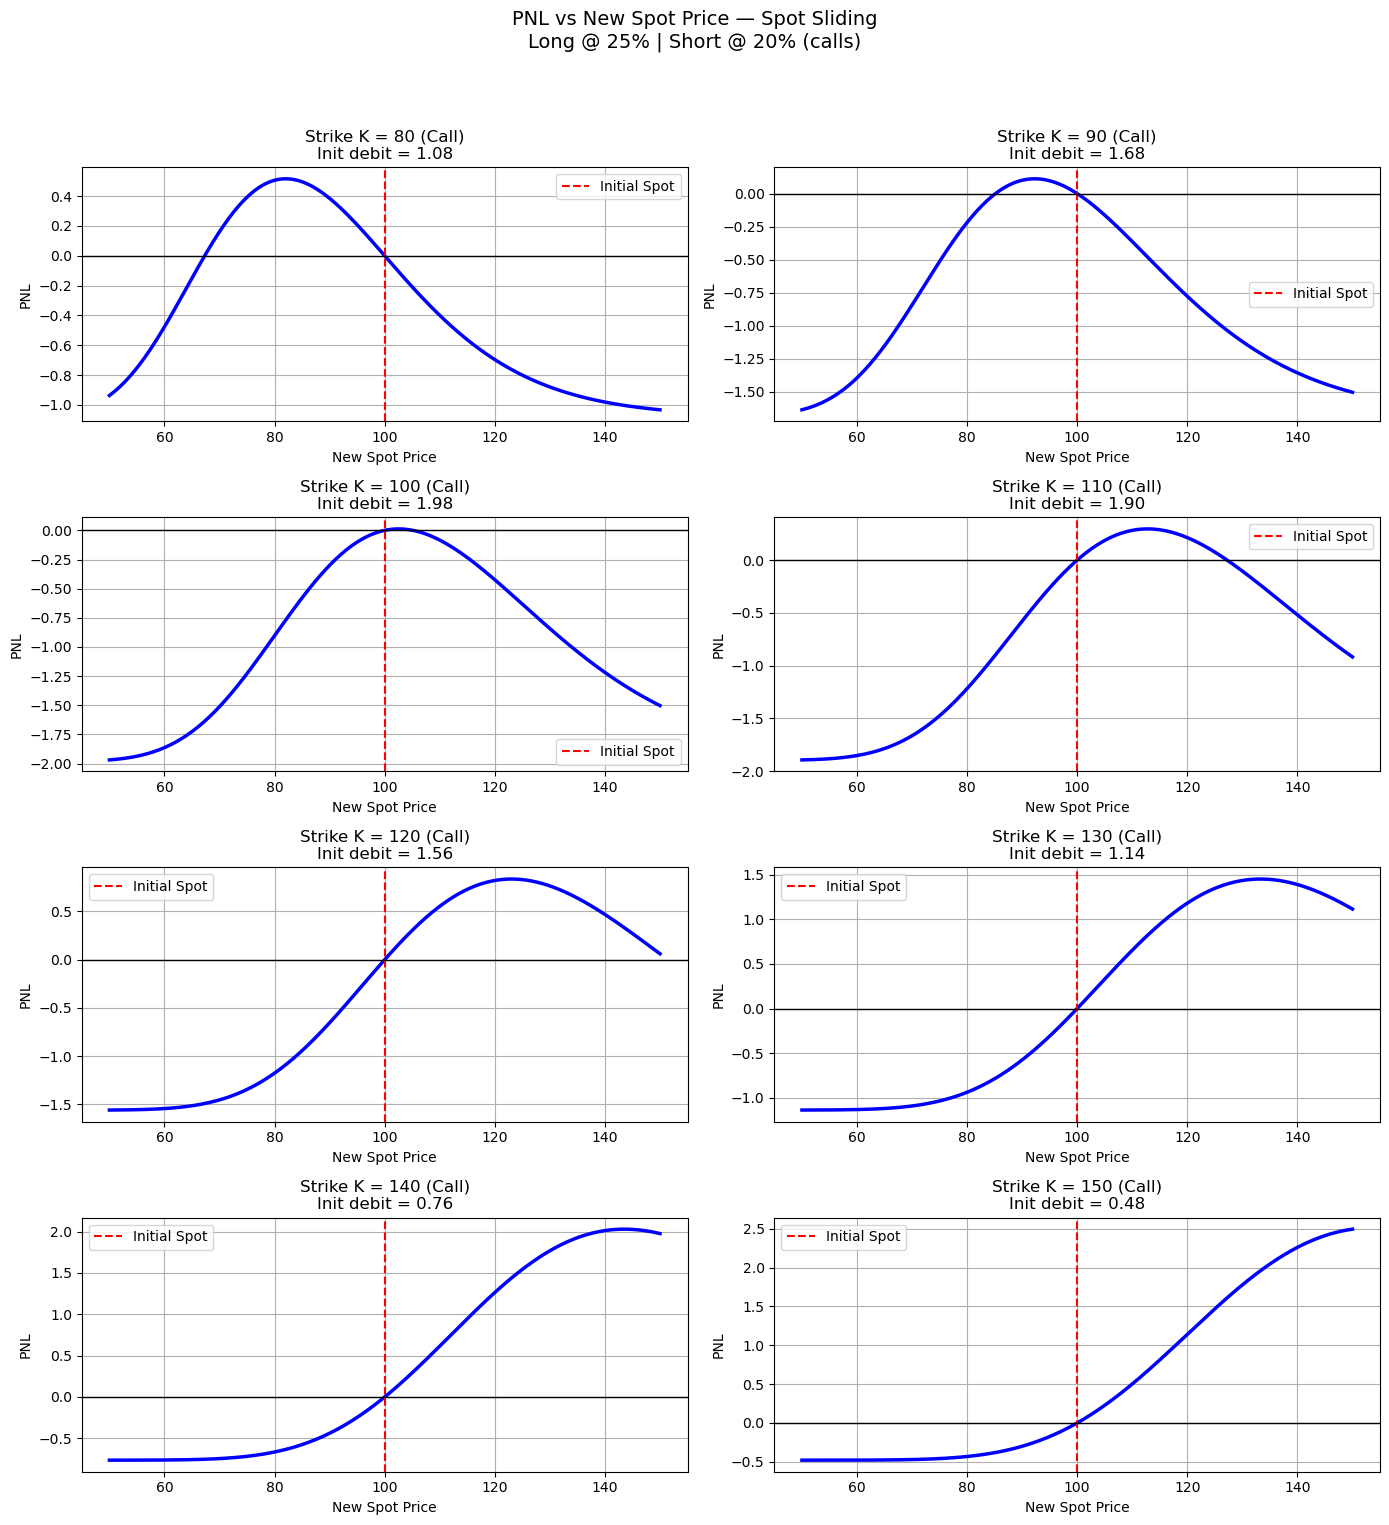

In [2]:
from cash_margin_pnl import *

=== VOL-SPREAD LSM SCRIPT (full version) ===
fitVol=20%, mgn=5%, σ_spot=20%
Saved: pnl_multi_strike_grid_spot_sliding_calls.png
Saved: expected_pnl_vs_strike_hold.png

=== HOLD vs LSM OPTIMAL UNWIND (per strike) ===
Strike   Init Debit     Hold E[PNL]   LSM Optimal E[PNL]     Improvement
---------------------------------------------------------------------------


/Users/xyx/.openclaw/workspace/project/warrant-vol-management/delivery/cash_margin_algo.py:11: RuntimeWarning: divide by zero encountered in scalar divide
  d1 = (np.log(S / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))


    80       1.0797         -0.0795               0.0000          0.0795
    90       1.6829         -0.3697              -0.0000          0.3697
   100       1.9821         -0.5103               0.0000          0.5103
   110       1.8984         -0.4303              -0.0000          0.4303
   120       1.5586         -0.2166               0.0000          0.2166
   130       1.1398          0.0081              -0.0000         -0.0081
   140       0.7639          0.1690               0.0000         -0.1690
   150       0.4794          0.2493               0.0000         -0.2493

Generating LSM unwind boundaries for EVERY strike (cash-out S* depends on K)...
Saved: pnl_unwind_boundaries_all_strikes_grid.png

✅ SCRIPT COMPLETE!
• Boundaries are now FULLY DECOUPLED per K (no more single K_atm).
• Each subplot shows how the cash-out spot S* evolves with time for that specific strike.
• Higher K → boundary shifts upward (you wait for spot to reach the higher strike).
• ATM (K=100) → unwind a

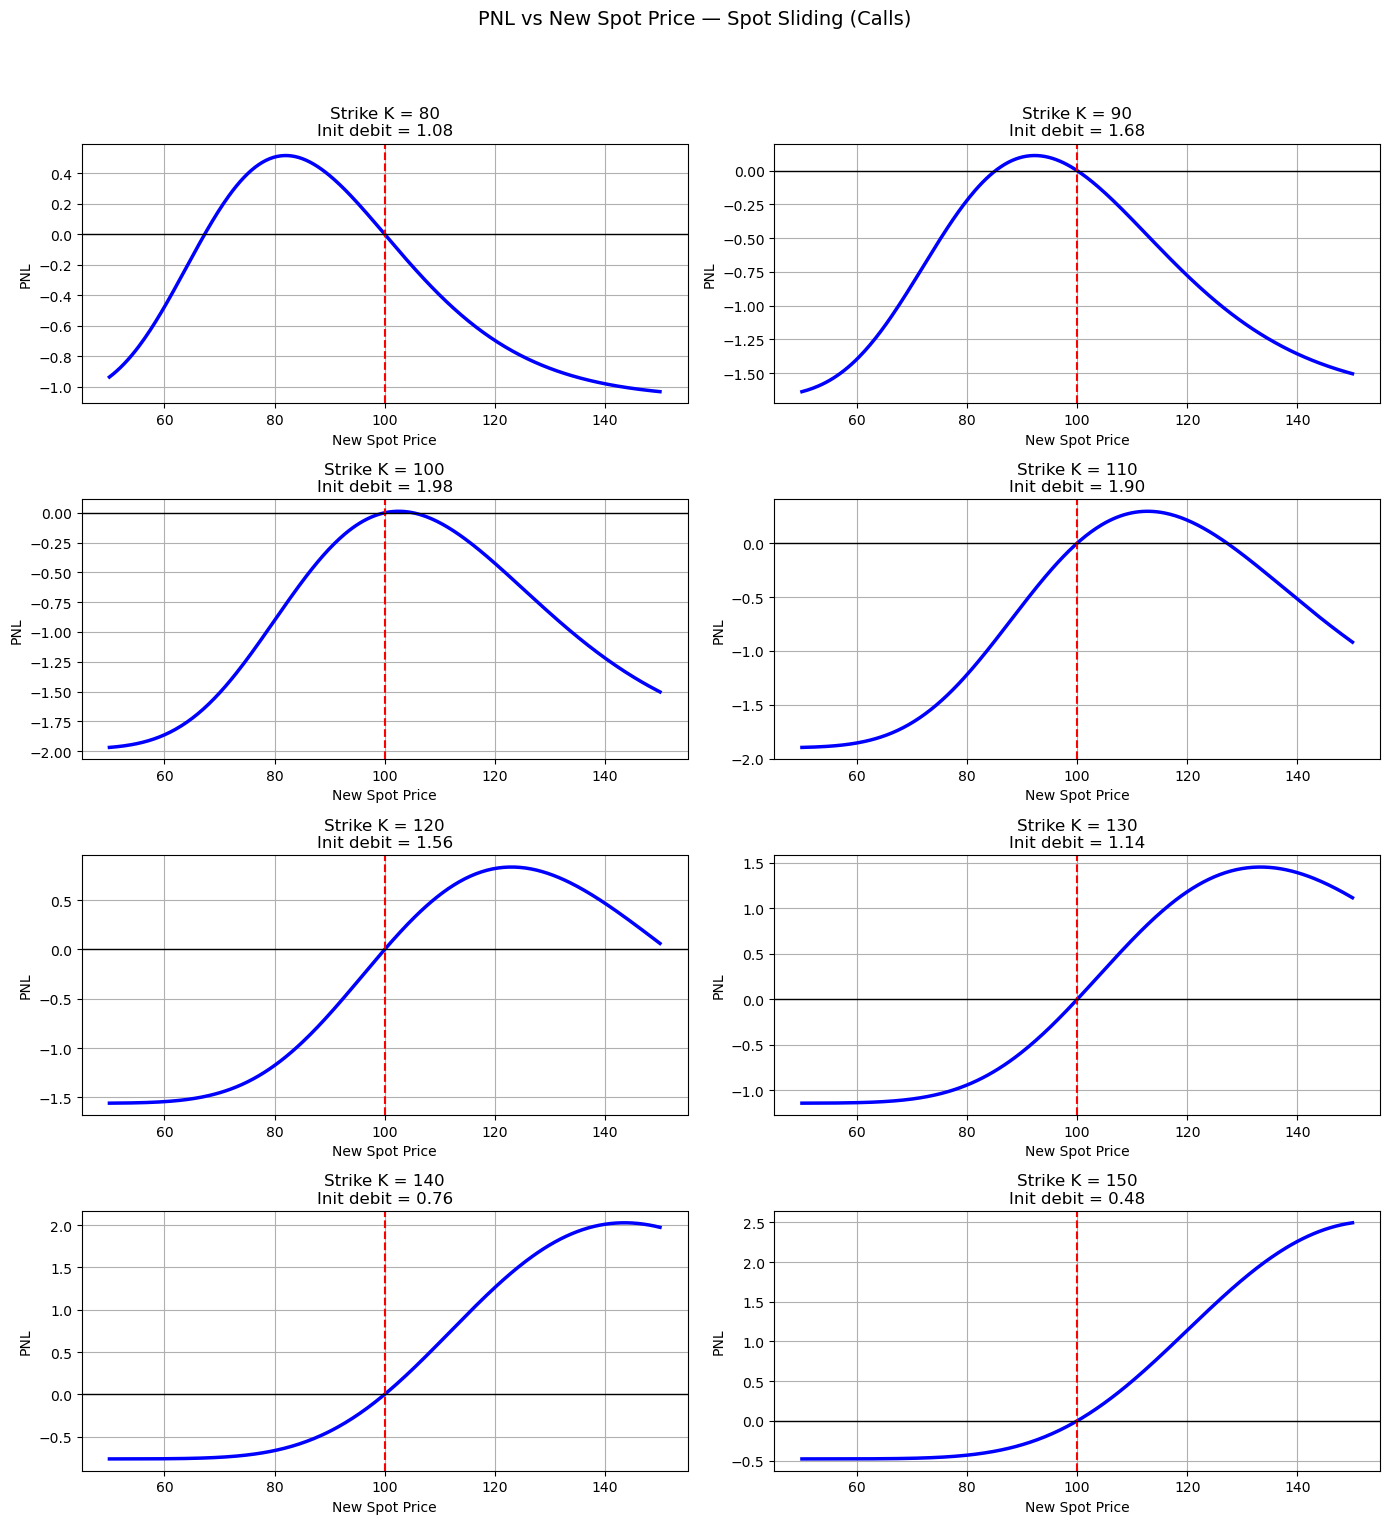

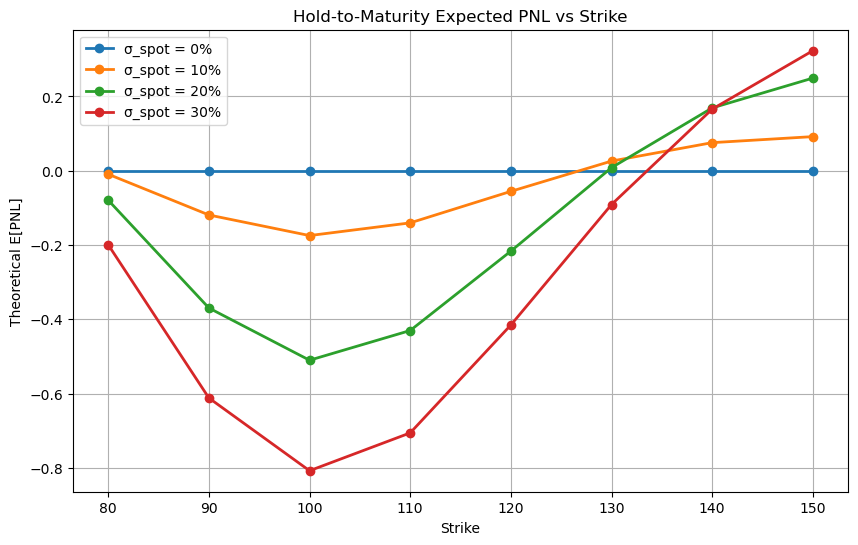

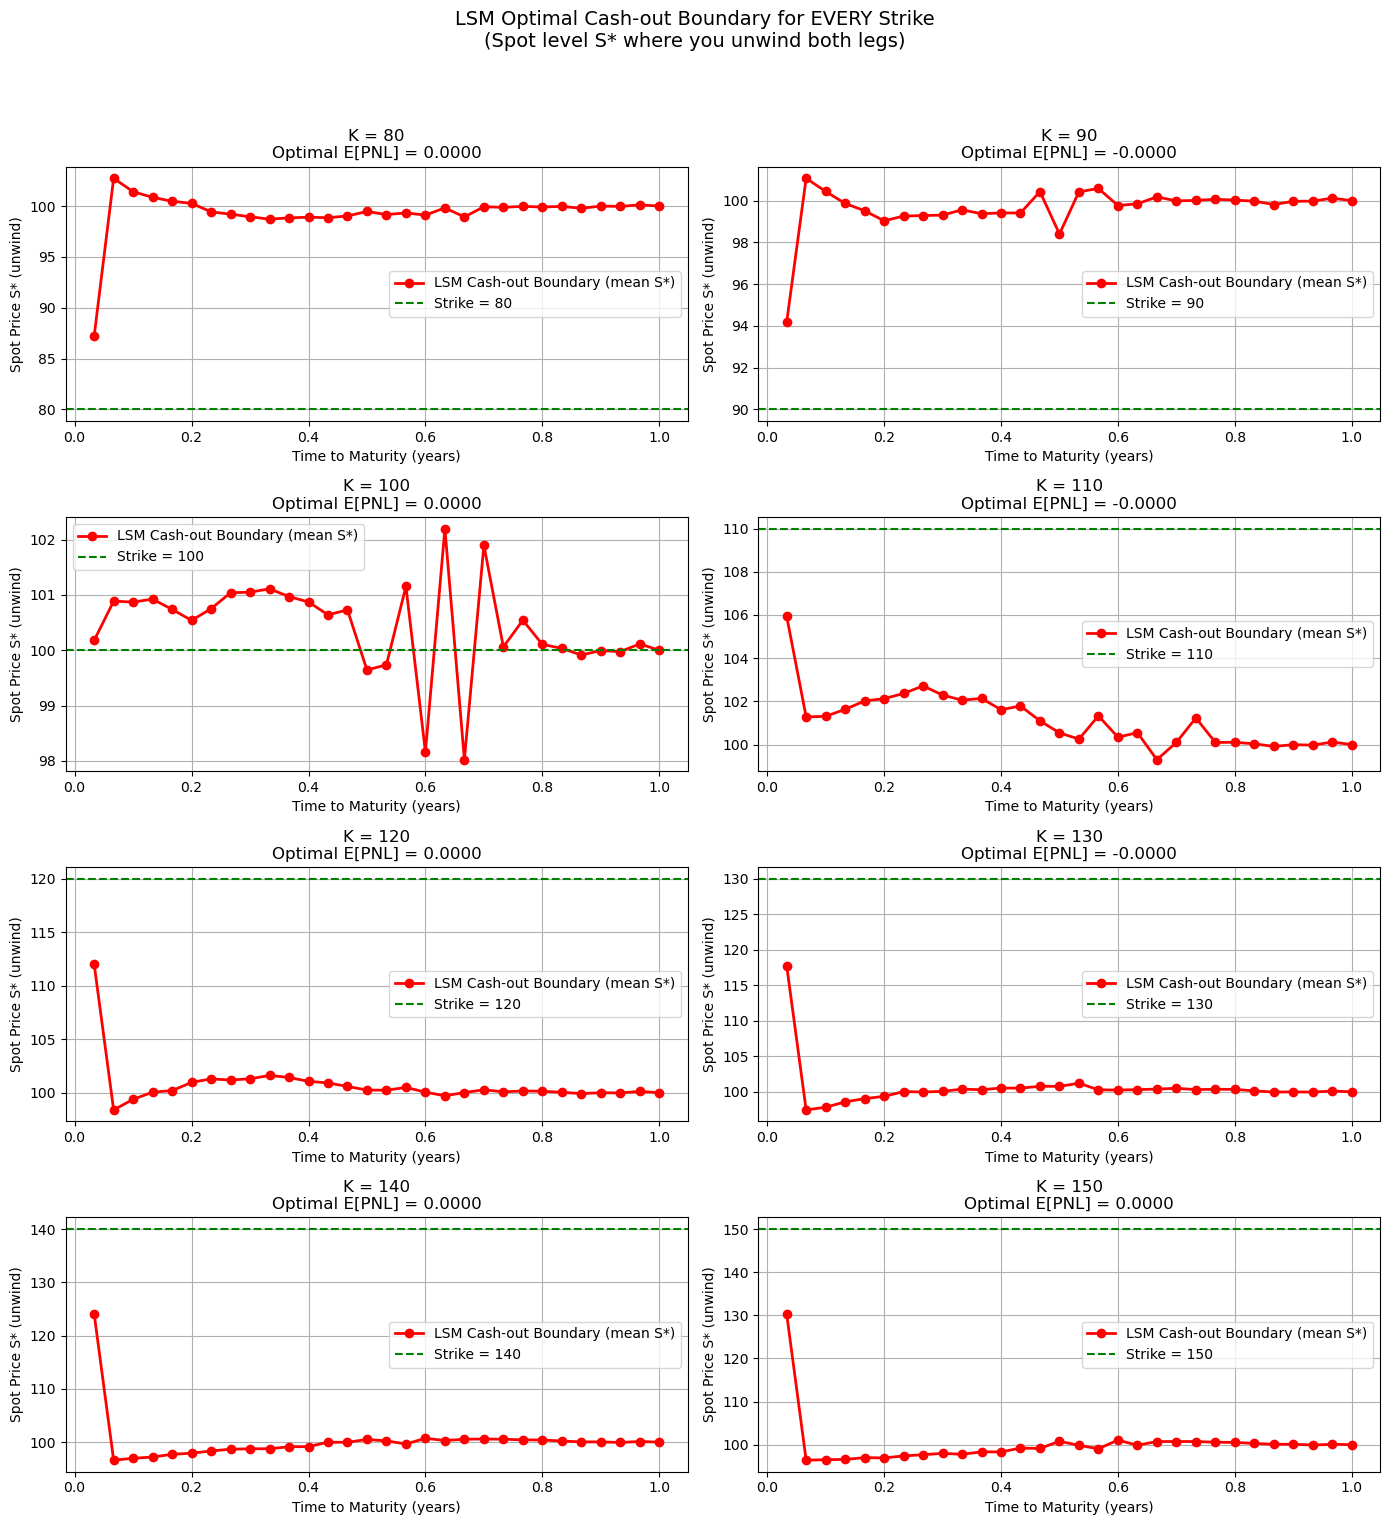

In [1]:
from cash_margin_algo import *

In [3]:
from test_optimal_unwind import run_tests

 SCENARIO 1: STATIC PNL CALCULATIONS (Hold to Maturity)  
Description: Compares the theoretical drift of the spread
against a Monte Carlo simulation if held to maturity T=1.

Target Strike : 100.0
Theo E[PnL]   : -0.5103
MC E[PnL]     : -0.5106
Conclusion: The high-vol leg bleeds edge over time. Holding to maturity yields negative or near-zero PnL depending on K.

 SCENARIO 2: OPTIMAL UNWIND (LSM vs PDE)                 
Description: Calculates the maximum expected PnL by finding
the optimal early-exercise stopping time.

Running LSM (Stochastic Regression)...


/Users/xyx/.openclaw/workspace/project/warrant-vol-management/delivery/cash_margin_algo.py:11: RuntimeWarning: divide by zero encountered in scalar divide
  d1 = (np.log(S / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))


Running PDE (HJB Finite Difference LCP)...


/Users/xyx/.openclaw/workspace/project/warrant-vol-management/delivery/optimal_unwind_pde_solver.py:9: RuntimeWarning: divide by zero encountered in log
  d1 = (np.log(S / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))



Results for Strike 100.0:
LSM Optimal E[PnL] : -0.0000
PDE Optimal E[PnL] : 0.0000
Conclusion: The PDE avoids the variance of Monte Carlo regression, usually finding a slightly tighter and more accurate optimal value.

=> Graph saved as 'pde_vs_lsm_boundary.png'


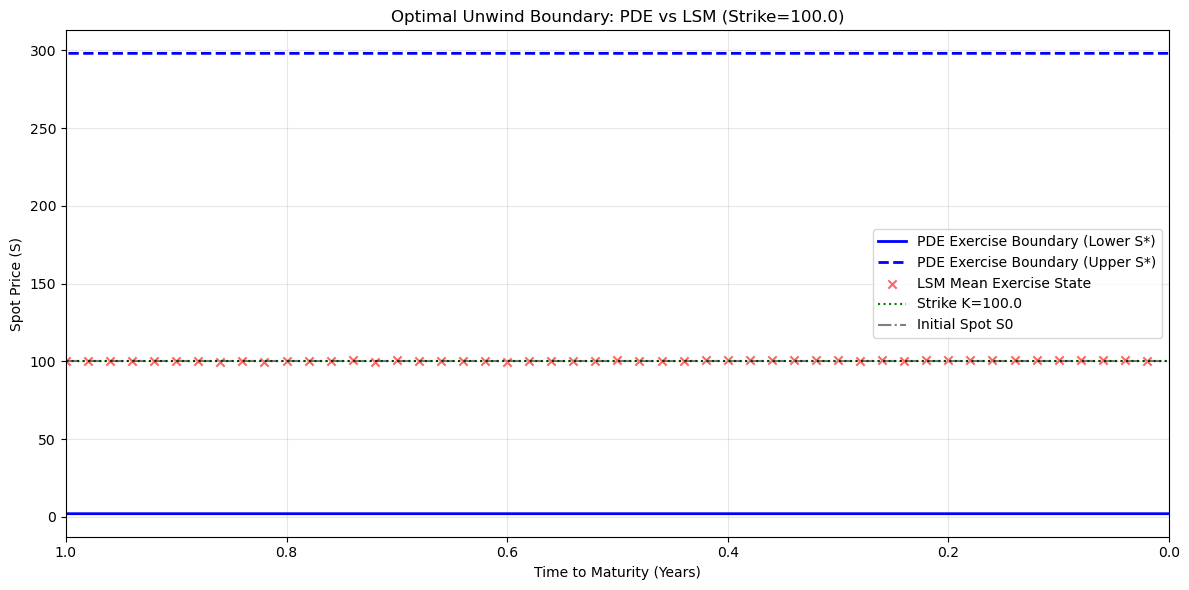

In [4]:
run_tests()

 SCENARIO 1: STATIC PNL CALCULATIONS (Hold to Maturity)  
Description: Compares the theoretical drift of the spread
against a Monte Carlo simulation if held to maturity T=1.

Target Strike : 140.0
Theo E[PnL]   : 0.1690
MC E[PnL]     : 0.1696
Conclusion: The high-vol leg bleeds edge over time. Holding to maturity yields negative or near-zero PnL depending on K.

 SCENARIO 2: OPTIMAL UNWIND (LSM vs PDE)                 
Description: Calculates the maximum expected PnL by finding
the optimal early-exercise stopping time.

Running LSM (Stochastic Regression)...
Running PDE (HJB Finite Difference LCP)...

Results for Strike 140.0:
LSM Optimal E[PnL] : 0.0000
PDE Optimal E[PnL] : 0.0004
Conclusion: The PDE avoids the variance of Monte Carlo regression, usually finding a slightly tighter and more accurate optimal value.

=> Graph saved as 'pde_vs_lsm_boundary.png'


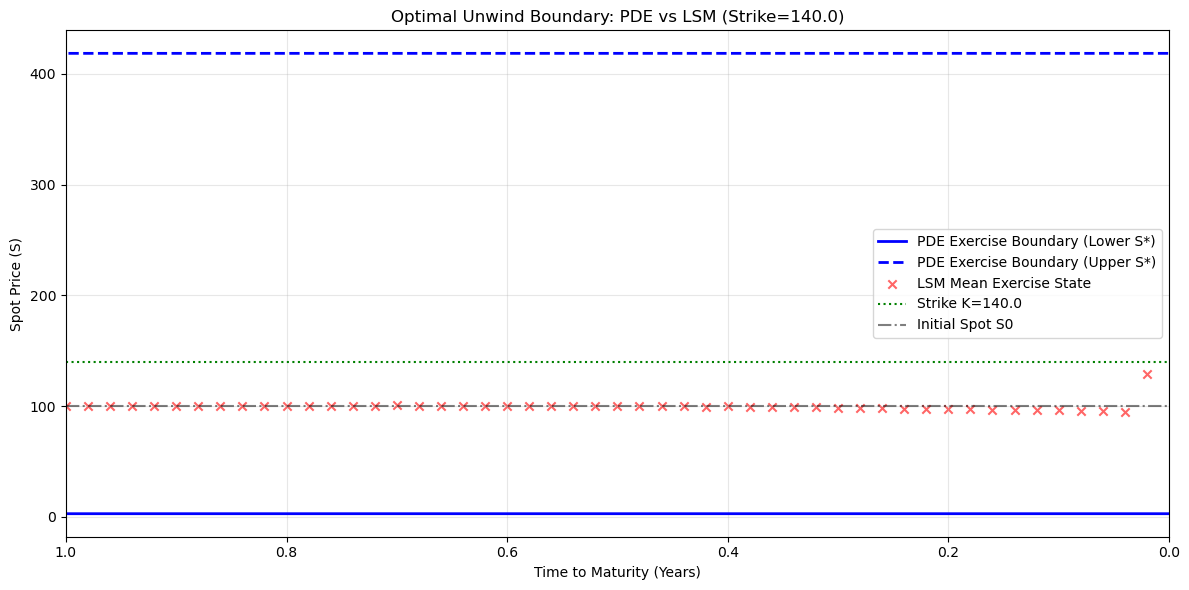

In [5]:
# Parameters for testing
S0 = 100.0
K = 140.0
T = 1.0
vol_high = 0.25
vol_base = 0.20
sigma_spot = 0.20
option_type = 'call'

print("=========================================================")
print(" SCENARIO 1: STATIC PNL CALCULATIONS (Hold to Maturity)  ")
print("=========================================================")
print("Description: Compares the theoretical drift of the spread")
print("against a Monte Carlo simulation if held to maturity T=1.")

theo_pnl = cma.theoretical_expected_pnl(K, vol_high, vol_base, sigma_spot, option_type, S0, T)
mc_pnl = cma.monte_carlo_expected_pnl(K, vol_high, vol_base, sigma_spot, option_type, n_samples=50000, S0=S0, T=T)

print(f"\nTarget Strike : {K}")
print(f"Theo E[PnL]   : {theo_pnl:.4f}")
print(f"MC E[PnL]     : {mc_pnl:.4f}")
print("Conclusion: The high-vol leg bleeds edge over time. Holding to maturity yields negative or near-zero PnL depending on K.")

print("\n=========================================================")
print(" SCENARIO 2: OPTIMAL UNWIND (LSM vs PDE)                 ")
print("=========================================================")
print("Description: Calculates the maximum expected PnL by finding")
print("the optimal early-exercise stopping time.")

# Run LSM
print("\nRunning LSM (Stochastic Regression)...")
lsm_pnl, lsm_S, lsm_ttm, _ = cma.lsm_optimal_pnl(K, vol_high, vol_base, sigma_spot, option_type, n_paths=5000, n_steps=50, S0=S0, T=T)

# Run PDE
print("Running PDE (HJB Finite Difference LCP)...")
pde_pnl, pde_spread, pde_S_min, pde_S_max, pde_ttm = pde_solver.pde_optimal_unwind(K, vol_high, vol_base, sigma_spot, option_type, T=T, S0=S0)

print(f"\nResults for Strike {K}:")
print(f"LSM Optimal E[PnL] : {lsm_pnl:.4f}")
print(f"PDE Optimal E[PnL] : {pde_pnl:.4f}")
print("Conclusion: The PDE avoids the variance of Monte Carlo regression, usually finding a slightly tighter and more accurate optimal value.")

# Graphing the Boundaries
plt.figure(figsize=(12, 6))

# Plot PDE Boundaries
plt.plot(pde_ttm, pde_S_min, 'b-', linewidth=2, label='PDE Exercise Boundary (Lower S*)')
plt.plot(pde_ttm, pde_S_max, 'b--', linewidth=2, label='PDE Exercise Boundary (Upper S*)')

# Plot LSM Boundaries (Mean S*)
# Note: LSM usually extracts a mean exercise point per time step, not strict upper/lower bounds.
plt.scatter(lsm_ttm, lsm_S, color='red', marker='x', alpha=0.6, label='LSM Mean Exercise State')

plt.axhline(K, color='green', linestyle=':', label=f'Strike K={K}')
plt.axhline(S0, color='black', linestyle='-.', alpha=0.5, label='Initial Spot S0')

plt.title(f'Optimal Unwind Boundary: PDE vs LSM (Strike={K})')
plt.xlabel('Time to Maturity (Years)')
plt.ylabel('Spot Price (S)')
plt.xlim(1.0, 0.0) # Standard to show TTM decreasing from left to right
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('pde_vs_lsm_boundary.png', dpi=300)
print("\n=> Graph saved as 'pde_vs_lsm_boundary.png'")
plt.show()


In [2]:
from test_optimal_unwind2 import *


SPOT SCENARIO TEST


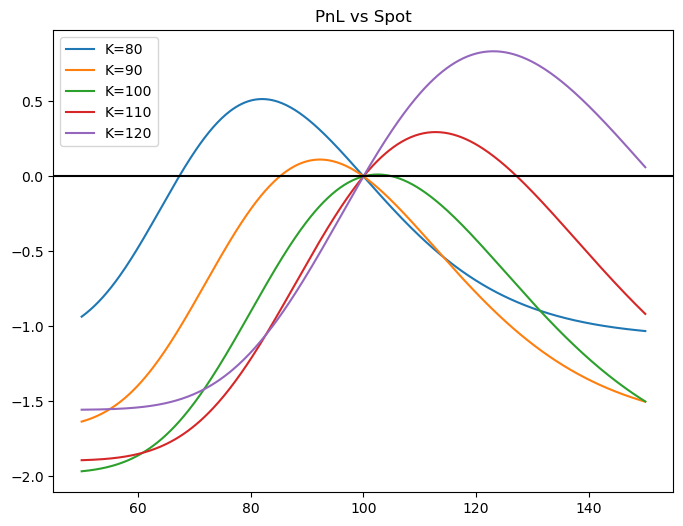


EXPECTED PNL VALIDATION
80 -0.07953624994807029 -0.07953624994807065 -0.0790785628306237
90 -0.3697240292943036 -0.3697240292942907 -0.36986820777298557
100 -0.5103238812155908 -0.5103238812155924 -0.5080787771225005
110 -0.43033595689998805 -0.43033595689998444 -0.43041537083671394
120 -0.21660244100198156 -0.2166024410019664 -0.21717862327892457

LSM vs PDE COMPARISON
Strike 80
LSM PnL 0.0


/Users/xyx/.openclaw/workspace/project/warrant-vol-management/delivery/test_optimal_unwind2.py:22: RuntimeWarning: divide by zero encountered in log
  d1=(np.log(S/K)+(r+0.5*sigma**2)*T)/(sigma*np.sqrt(T))


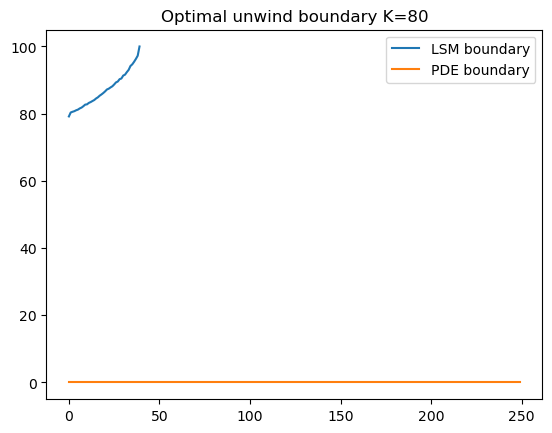

Strike 100
LSM PnL 0.0


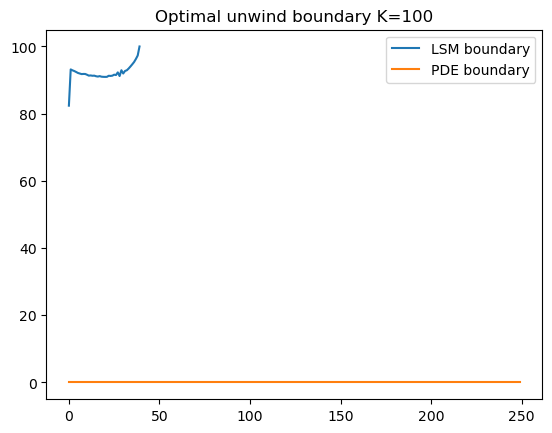

Strike 120
LSM PnL -2.220446049250313e-16


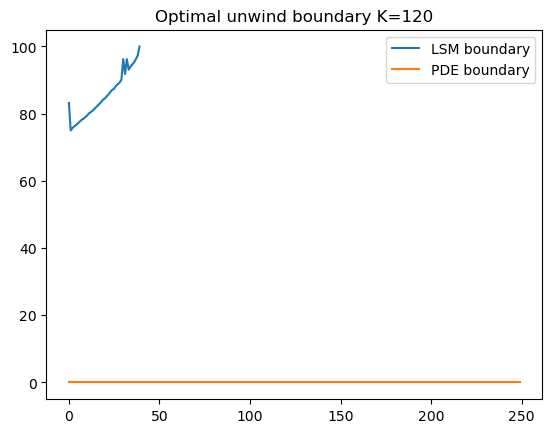

In [3]:
test_spot_scenarios()

test_expected()

test_optimal()

In [6]:
def pde_solver(
    K,
    vol_h,
    vol_b,
    sigma,
    S0=100,
    Smax=300,
    Ns=300,
    Nt=300,
    T=1.0,
    r=0.0
):

    S = np.linspace(0, Smax, Ns)
    dS = S[1] - S[0]
    dt = T / Nt

    V = np.zeros(Ns)

    boundary = []

    for n in range(Nt):

        tau = T - n*dt

        Phi = spread_price(S, K, vol_h, vol_b, tau)

        # implicit matrix
        a = np.zeros(Ns)
        b = np.zeros(Ns)
        c = np.zeros(Ns)

        for i in range(1, Ns-1):

            A = 0.5 * sigma**2 * S[i]**2 / dS**2
            B = r * S[i] / (2*dS)

            a[i] = -dt*(A - B)
            b[i] = 1 + dt*(2*A + r)
            c[i] = -dt*(A + B)

        V_new = V.copy()

        # projected Gauss-Seidel
        for _ in range(50):

            for i in range(1, Ns-1):

                cont = (
                    a[i]*V_new[i-1]
                    + c[i]*V_new[i+1]
                    + V[i]
                ) / b[i]

                V_new[i] = max(cont, Phi[i])

        V = V_new

        exercise = V <= Phi + 1e-8

        if np.any(exercise):
            boundary.append(S[exercise].max())
        else:
            boundary.append(np.nan)

    return S, V, boundary

In [9]:
pde_solver(150,
    0.26,
    0.2,
    0.3)

(array([  0.        ,   1.00334448,   2.00668896,   3.01003344,
          4.01337793,   5.01672241,   6.02006689,   7.02341137,
          8.02675585,   9.03010033,  10.03344482,  11.0367893 ,
         12.04013378,  13.04347826,  14.04682274,  15.05016722,
         16.05351171,  17.05685619,  18.06020067,  19.06354515,
         20.06688963,  21.07023411,  22.0735786 ,  23.07692308,
         24.08026756,  25.08361204,  26.08695652,  27.090301  ,
         28.09364548,  29.09698997,  30.10033445,  31.10367893,
         32.10702341,  33.11036789,  34.11371237,  35.11705686,
         36.12040134,  37.12374582,  38.1270903 ,  39.13043478,
         40.13377926,  41.13712375,  42.14046823,  43.14381271,
         44.14715719,  45.15050167,  46.15384615,  47.15719064,
         48.16053512,  49.1638796 ,  50.16722408,  51.17056856,
         52.17391304,  53.17725753,  54.18060201,  55.18394649,
         56.18729097,  57.19063545,  58.19397993,  59.19732441,
         60.2006689 ,  61.20401338,  62.


SPOT PNL SCENARIOS


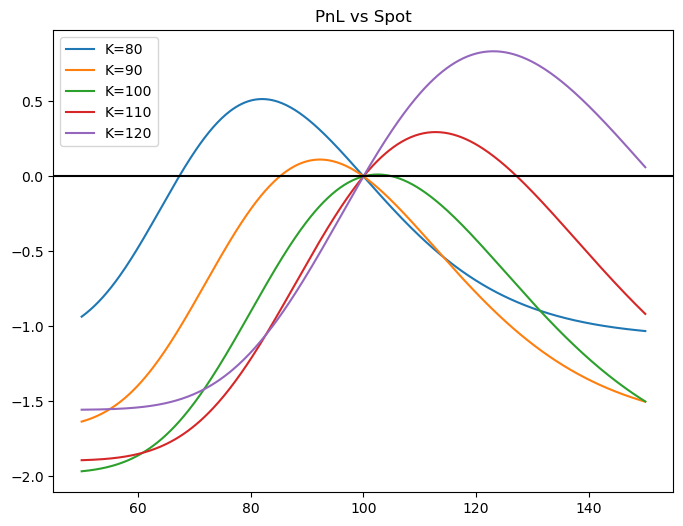


EXPECTED PNL VALIDATION
K=80 theo=-0.0795 num=-0.0795 mc=-0.0793
K=90 theo=-0.3697 num=-0.3697 mc=-0.3697
K=100 theo=-0.5103 num=-0.5103 mc=-0.5109
K=110 theo=-0.4303 num=-0.4303 mc=-0.4311
K=120 theo=-0.2166 num=-0.2166 mc=-0.2141

LSM OPTIMAL BOUNDARY


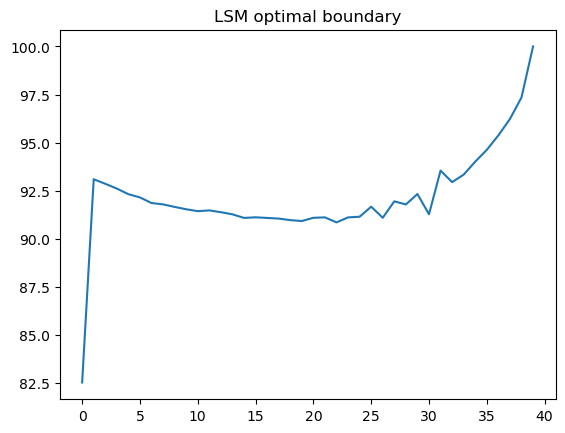


VOL SPREAD ARBITRAGE RESEARCH

===== USER PARAMETERS =====
K=140.0
S0=100.0
sigma_spot=0.3
vol_base=0.2
vol_high=0.25
vol_spread=0.04999999999999999
T=1.0


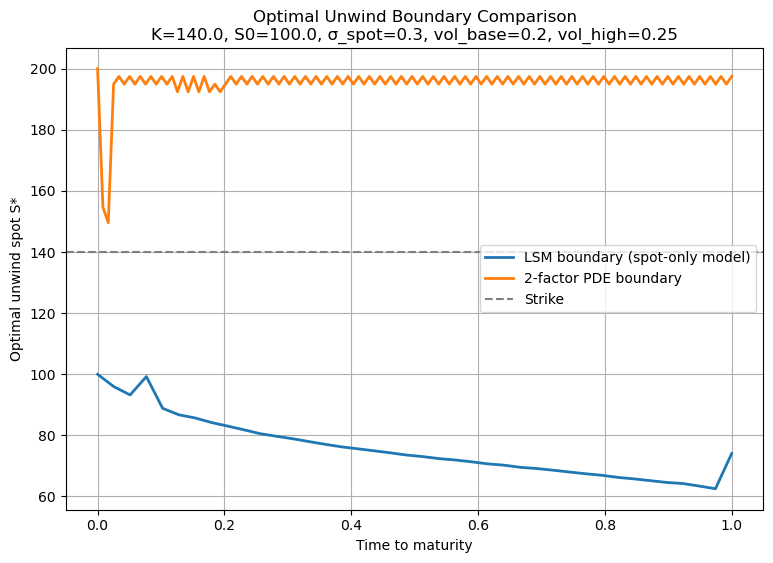


LSM expected optimal PnL: -1.1102230246251565e-16

2-FACTOR HJB SOLVER


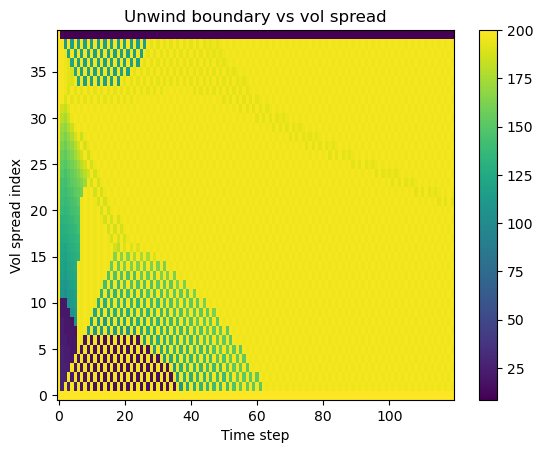

In [11]:
"""
VOL-SPREAD ARBITRAGE RESEARCH SUITE
===================================

Features
--------
1. Spot scenario PnL
2. Expected PnL validation
3. LSM optimal stopping
4. 2-factor HJB PDE solver
5. Diagnostic plots

State variables:
    Spot S
    Volatility spread Δσ

Author: Quant research framework
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, lognorm
from scipy.integrate import quad


# ================================================================
# BLACK-SCHOLES (vectorized)
# ================================================================

def bs_call(S,K,sigma,T,r=0):

    S=np.asarray(S)

    if T<=0:
        return np.maximum(S-K,0)

    d1=(np.log(S/K)+(r+0.5*sigma**2)*T)/(sigma*np.sqrt(T))
    d2=d1-sigma*np.sqrt(T)

    return S*norm.cdf(d1)-K*np.exp(-r*T)*norm.cdf(d2)


# ================================================================
# VOL-SPREAD PAYOFF
# ================================================================

def spread_price(S,K,vol_base,vol_spread,T):

    vol_high=vol_base+vol_spread

    return bs_call(S,K,vol_high,T)-bs_call(S,K,vol_base,T)


def pnl(S,S0,K,vol_base,vol_spread,T):

    debit=spread_price(S0,K,vol_base,vol_spread,T)

    return spread_price(S,K,vol_base,vol_spread,T)-debit


# ================================================================
# EXPECTED PNL METHODS
# ================================================================

def expected_theoretical(K,vol_base,vol_spread,sigma_spot,S0,T):

    sig_h=np.sqrt((vol_base+vol_spread)**2+sigma_spot**2)
    sig_b=np.sqrt(vol_base**2+sigma_spot**2)

    e_high=bs_call(S0,K,sig_h,T)
    e_base=bs_call(S0,K,sig_b,T)

    debit=spread_price(S0,K,vol_base,vol_spread,T)

    return e_high-e_base-debit


def expected_numeric(K,vol_base,vol_spread,sigma_spot,S0,T):

    def integrand(S):

        pdf=lognorm.pdf(S,s=sigma_spot,scale=S0*np.exp(-0.5*sigma_spot**2))

        return pnl(S,S0,K,vol_base,vol_spread,T)*pdf

    val,_=quad(integrand,0,500)

    return val


def expected_mc(K,vol_base,vol_spread,sigma_spot,S0,T,n=200000):

    Z=np.random.randn(n)

    S=S0*np.exp(-0.5*sigma_spot**2+sigma_spot*Z)

    return np.mean(pnl(S,S0,K,vol_base,vol_spread,T))


# ================================================================
# SPOT PATH SIMULATION
# ================================================================

def simulate_spot(S0,sigma,T,steps,paths):

    dt=T/steps

    S=np.zeros((paths,steps+1))
    S[:,0]=S0

    for i in range(1,steps+1):

        Z=np.random.randn(paths)

        S[:,i]=S[:,i-1]*np.exp(-0.5*sigma**2*dt+sigma*np.sqrt(dt)*Z)

    return S


# ================================================================
# LSM OPTIMAL STOPPING (spot only)
# ================================================================

def lsm_solver(K,vol_base,vol_spread,sigma_spot,S0,T,
               paths=15000,steps=40):

    dt=T/steps

    S=simulate_spot(S0,sigma_spot,T,steps,paths)

    V=np.zeros(paths)

    boundary=[]

    for step in reversed(range(steps)):

        tau=(steps-step)*dt

        spot=S[:,step]

        exercise=spread_price(spot,K,vol_base,vol_spread,tau)

        X=spot/K

        basis=np.column_stack([np.ones(paths),X,X**2])

        coef=np.linalg.lstsq(basis,V,rcond=None)[0]

        continuation=basis@coef

        ex=exercise>continuation

        if np.any(ex):
            boundary.append(np.percentile(spot[ex],20))
        else:
            boundary.append(np.nan)

        V[ex]=exercise[ex]

    debit=spread_price(S0,K,vol_base,vol_spread,T)

    return np.mean(V)-debit,boundary


# ================================================================
# 2-FACTOR HJB PDE SOLVER
# ================================================================

def hjb_2factor_solver(
        K,
        vol_base,
        S0=100,
        Smax=200,
        dS=80,
        vol_spread_max=0.2,
        dv=40,
        T=1,
        Nt=120,
        sigma_spot=0.2,
        kappa=3,
        theta=0.05,
        eta=0.15):

    S=np.linspace(1,Smax,dS)
    V=np.linspace(0,vol_spread_max,dv)

    dt=T/Nt

    value=np.zeros((dS,dv))

    boundary=[]

    for n in range(Nt):

        tau=T-n*dt

        Phi=np.zeros_like(value)

        for i in range(dS):
            for j in range(dv):

                Phi[i,j]=spread_price(
                    S[i],
                    K,
                    vol_base,
                    V[j],
                    tau
                )

        new_val=value.copy()

        for i in range(1,dS-1):
            for j in range(1,dv-1):

                dS1=(value[i+1,j]-value[i-1,j])/(2*(S[1]-S[0]))
                dS2=(value[i+1,j]-2*value[i,j]+value[i-1,j])/(S[1]-S[0])**2

                dv1=(value[i,j+1]-value[i,j-1])/(2*(V[1]-V[0]))
                dv2=(value[i,j+1]-2*value[i,j]+value[i,j-1])/(V[1]-V[0])**2

                drift_spot=0.5*sigma_spot**2*S[i]**2*dS2
                drift_vol=kappa*(theta-V[j])*dv1+0.5*eta**2*dv2

                new_val[i,j]=value[i,j]+dt*(drift_spot+drift_vol)

        value=np.maximum(new_val,Phi)

        boundary_slice=[]

        for j in range(dv):

            ex=value[:,j]<=Phi[:,j]+1e-8

            if np.any(ex):
                boundary_slice.append(S[ex].max())
            else:
                boundary_slice.append(np.nan)

        boundary.append(boundary_slice)

    return S,V,value,boundary


# ================================================================
# TESTS
# ================================================================

def test_spot_scenarios():

    print("\nSPOT PNL SCENARIOS")

    S0=100
    T=1
    vol_base=0.20
    vol_spread=0.05

    strikes=[80,90,100,110,120]

    S=np.linspace(50,150,400)

    plt.figure(figsize=(8,6))

    for K in strikes:

        plt.plot(S,pnl(S,S0,K,vol_base,vol_spread,T),label=f"K={K}")

    plt.axhline(0,color="black")

    plt.title("PnL vs Spot")

    plt.legend()

    plt.show()


def test_expected():

    print("\nEXPECTED PNL VALIDATION")

    S0=100
    sigma=0.2
    vol_base=0.20
    vol_spread=0.05
    T=1

    strikes=[80,90,100,110,120]

    for K in strikes:

        theo=expected_theoretical(K,vol_base,vol_spread,sigma,S0,T)
        num=expected_numeric(K,vol_base,vol_spread,sigma,S0,T)
        mc=expected_mc(K,vol_base,vol_spread,sigma,S0,T)

        print(f"K={K} theo={theo:.4f} num={num:.4f} mc={mc:.4f}")


def test_lsm():

    print("\nLSM OPTIMAL BOUNDARY")

    S0=100
    sigma=0.2
    vol_base=0.20
    vol_spread=0.05
    T=1
    K=100

    pnl,boundary=lsm_solver(K,vol_base,vol_spread,sigma,S0,T)

    plt.plot(boundary)

    plt.title("LSM optimal boundary")

    plt.show()


def test_hjb():

    print("\n2-FACTOR HJB SOLVER")

    K=100
    vol_base=0.20

    S,V,val,boundary=hjb_2factor_solver(K,vol_base)

    boundary=np.array(boundary)

    plt.imshow(boundary.T,
               origin="lower",
               aspect="auto")

    plt.colorbar()

    plt.title("Unwind boundary vs vol spread")

    plt.xlabel("Time step")

    plt.ylabel("Vol spread index")

    plt.show()

def compare_lsm_pde_boundary(
        K=100,
        S0=100,
        sigma_spot=0.20,
        vol_base=0.20,
        vol_high=0.25,
        T=1.0):

    vol_spread = vol_high - vol_base

    print("\n===== USER PARAMETERS =====")
    print(f"K={K}")
    print(f"S0={S0}")
    print(f"sigma_spot={sigma_spot}")
    print(f"vol_base={vol_base}")
    print(f"vol_high={vol_high}")
    print(f"vol_spread={vol_spread}")
    print(f"T={T}")

    # ---------------- LSM ----------------
    lsm_pnl, lsm_boundary = lsm_solver(
        K,
        vol_base,
        vol_spread,
        sigma_spot,
        S0,
        T
    )

    lsm_boundary = np.array(lsm_boundary)
    lsm_boundary = lsm_boundary[::-1]

    time_lsm = np.linspace(0, T, len(lsm_boundary))

    # ---------------- PDE ----------------
    S, V, val, pde_surface = hjb_2factor_solver(
        K,
        vol_base,
        S0=S0,
        sigma_spot=sigma_spot,
        T=T
    )

    pde_surface = np.array(pde_surface)

    # choose vol_spread slice closest to initial spread
    vol_grid = V
    idx = np.argmin(np.abs(vol_grid - vol_spread))

    pde_boundary = pde_surface[:, idx]

    time_pde = np.linspace(0, T, len(pde_boundary))

    # ---------------- Plot ----------------

    plt.figure(figsize=(9,6))

    plt.plot(
        time_lsm,
        lsm_boundary,
        label="LSM boundary (spot-only model)",
        linewidth=2
    )

    plt.plot(
        time_pde,
        pde_boundary,
        label="2-factor PDE boundary",
        linewidth=2
    )

    plt.axhline(K, linestyle="--", color="gray", label="Strike")

    plt.xlabel("Time to maturity")
    plt.ylabel("Optimal unwind spot S*")

    plt.title(
        f"Optimal Unwind Boundary Comparison\n"
        f"K={K}, S0={S0}, σ_spot={sigma_spot}, "
        f"vol_base={vol_base}, vol_high={vol_high}"
    )

    plt.legend()
    plt.grid()

    plt.show()

    print("\nLSM expected optimal PnL:", lsm_pnl)

def test_lsm_hjb():

    print("\nVOL SPREAD ARBITRAGE RESEARCH")

    K = float(input("Strike K (default 100): ") or 100)
    S0 = float(input("Spot S0 (default 100): ") or 100)
    sigma_spot = float(input("Spot vol sigma_spot (default 0.2): ") or 0.2)
    vol_base = float(input("Base implied vol (default 0.20): ") or 0.20)
    vol_high = float(input("High implied vol (default 0.25): ") or 0.25)
    T = float(input("Maturity T years (default 1): ") or 1)

    compare_lsm_pde_boundary(
        K=K,
        S0=S0,
        sigma_spot=sigma_spot,
        vol_base=vol_base,
        vol_high=vol_high,
        T=T
    )

# ================================================================
# MAIN
# ================================================================

if __name__=="__main__":

    test_spot_scenarios()

    test_expected()

    test_lsm()
    test_lsm_hjb()
    test_hjb()

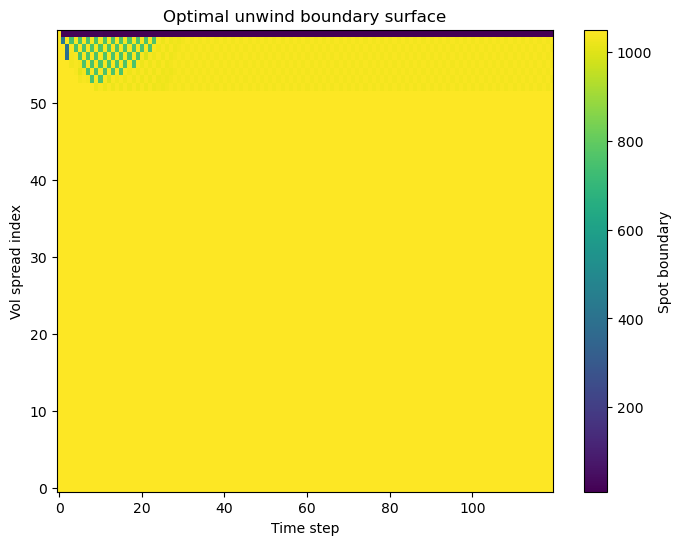

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm


# -------------------------------------------------
# Black-Scholes
# -------------------------------------------------

def bs_call(S,K,sigma,T,r=0):

    if T<=0:
        return np.maximum(S-K,0)

    d1=(np.log(S/K)+(r+0.5*sigma**2)*T)/(sigma*np.sqrt(T))
    d2=d1-sigma*np.sqrt(T)

    return S*norm.cdf(d1)-K*np.exp(-r*T)*norm.cdf(d2)


# -------------------------------------------------
# Vol spread payoff
# -------------------------------------------------

def spread_price(S,K,vol_base,spread,T):

    return bs_call(S,K,vol_base+spread,T)-bs_call(S,K,vol_base,T)


# -------------------------------------------------
# 2-factor PDE solver
# -------------------------------------------------

def hjb_solver(K,S0,vol_base,
               sigma_spot=0.2,
               kappa=3,
               theta=0.02,
               eta=0.10,
               Smax=1050,
               spread_max=0.15,
               Ns=120,
               Nv=60,
               Nt=120,
               T=1):

    S=np.linspace(1,Smax,Ns)
    V=np.linspace(0,spread_max,Nv)

    dt=T/Nt

    val=np.zeros((Ns,Nv))

    boundary=[]

    for n in range(Nt):

        tau=T-n*dt

        payoff=np.zeros_like(val)

        for i in range(Ns):
            for j in range(Nv):

                payoff[i,j]=spread_price(S[i],K,vol_base,V[j],tau)

        new_val=val.copy()

        for i in range(1,Ns-1):
            for j in range(1,Nv-1):

                dS=S[1]-S[0]
                dv=V[1]-V[0]

                VS=(val[i+1,j]-val[i-1,j])/(2*dS)
                VSS=(val[i+1,j]-2*val[i,j]+val[i-1,j])/(dS*dS)

                VV=(val[i,j+1]-val[i,j-1])/(2*dv)
                VVV=(val[i,j+1]-2*val[i,j]+val[i,j-1])/(dv*dv)

                spot_term=0.5*sigma_spot**2*S[i]**2*VSS
                vol_term=kappa*(theta-V[j])*VV+0.5*eta**2*VVV

                new_val[i,j]=val[i,j]+dt*(spot_term+vol_term)

        val=np.maximum(new_val,payoff)

        # boundary detection
        slice_boundary=[]

        for j in range(Nv):

            ex=val[:,j]<=payoff[:,j]+1e-8

            if np.any(ex):
                slice_boundary.append(S[ex].max())
            else:
                slice_boundary.append(np.nan)

        boundary.append(slice_boundary)

    return S,V,val,np.array(boundary)


# -------------------------------------------------
# Boundary visualization
# -------------------------------------------------

def plot_boundary(K,S0,vol_base):

    S,V,val,boundary=hjb_solver(K,S0,vol_base)

    plt.figure(figsize=(8,6))

    plt.imshow(boundary.T,
               origin='lower',
               aspect='auto')

    plt.colorbar(label="Spot boundary")

    plt.xlabel("Time step")
    plt.ylabel("Vol spread index")

    plt.title("Optimal unwind boundary surface")

    plt.show()


# -------------------------------------------------
# Example run
# -------------------------------------------------

if __name__=="__main__":

    K=140
    S0=100
    vol_base=0.20

    plot_boundary(K,S0,vol_base)